In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrexibiza/grocery-sales-dataset")

print("Path to dataset files:", path)

C:\Users\supor\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 223M/223M [00:17<00:00, 13.4MB/s] 

Extracting files...


Path to dataset files: C:\Users\supor\.cache\kagglehub\datasets\andrexibiza\grocery-sales-dataset\versions\3


In [3]:
import shutil
from pathlib import Path

# Salva (copia) os arquivos do dataset em uma subpasta "dados"
destino = Path("dados")
destino.mkdir(exist_ok=True)

for arquivo in Path(path).glob("*"):
    if arquivo.is_file():
        shutil.copy2(arquivo, destino / arquivo.name)

print("Dados salvos em:", destino.resolve())
print("Arquivos:", [f.name for f in destino.iterdir()])

Dados salvos em: C:\workspace\codigos\PI-6-TIME1\dados
Arquivos: ['categories.csv', 'cities.csv', 'countries.csv', 'customers.csv', 'employees.csv', 'products.csv', 'sales.csv']


# Análise Exploratória — Grocery Sales Dataset
Base relacional de vendas de supermercado (Kaggle `andrexibiza/grocery-sales-dataset`).
As células abaixo carregam os dados da pasta `dados/` e fazem a EDA.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
AZUL = "#2563eb"
DADOS = Path("dados")

## 1. Carregar as tabelas

In [5]:
categories = pd.read_csv(DADOS/"categories.csv")
cities     = pd.read_csv(DADOS/"cities.csv")
countries  = pd.read_csv(DADOS/"countries.csv")
customers  = pd.read_csv(DADOS/"customers.csv")
employees  = pd.read_csv(DADOS/"employees.csv", parse_dates=["BirthDate", "HireDate"])
products   = pd.read_csv(DADOS/"products.csv", parse_dates=["ModifyDate"])

# sales e grande (~6.7M linhas) -> especificar dtypes economiza memoria
dtypes_sales = {"SalesID":"int64", "SalesPersonID":"int32", "CustomerID":"int32",
                "ProductID":"int32", "Quantity":"int32", "Discount":"float32",
                "TotalPrice":"float32"}
sales = pd.read_csv(DADOS/"sales.csv", dtype=dtypes_sales, parse_dates=["SalesDate"])

tabelas = {"categories":categories, "cities":cities, "countries":countries,
           "customers":customers, "employees":employees, "products":products, "sales":sales}
pd.DataFrame({"linhas":[len(d) for d in tabelas.values()],
              "colunas":[d.shape[1] for d in tabelas.values()]}, index=tabelas.keys())

,linhas,colunas
categories,11,2
cities,96,4
countries,206,3
customers,98759,6
employees,23,8
products,452,9
sales,6758125,9


## 2. Qualidade dos dados — valores ausentes e duplicatas

In [6]:
for nome, df in tabelas.items():
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    print(f"{nome}:", dict(nulos) if len(nulos) else "sem valores ausentes")

print("\nDuplicatas SalesID:", sales.SalesID.duplicated().sum())
print("Duplicatas CustomerID:", customers.CustomerID.duplicated().sum())

categories: sem valores ausentes
cities: sem valores ausentes
countries: {'CountryCode': np.int64(1)}
customers: {'MiddleInitial': np.int64(977)}
employees: sem valores ausentes
products: sem valores ausentes
sales: {'SalesDate': np.int64(67526)}

Duplicatas SalesID: 0
Duplicatas CustomerID: 0


## 3. Achado importante: `TotalPrice`
A coluna `TotalPrice` vem **100% zerada**. Reconstruímos a receita a partir de
`products.Price`: `Receita = Quantity × Price × (1 - Discount)`.

In [7]:
frac_zero = (sales.TotalPrice == 0).mean()
print(f"TotalPrice zerada em {frac_zero*100:.1f}% das linhas")

sales = sales.merge(products[["ProductID", "Price", "CategoryID"]], on="ProductID", how="left")
sales["Receita"] = sales["Quantity"] * sales["Price"] * (1 - sales["Discount"])

print(f"Receita total estimada: R$ {sales['Receita'].sum():,.0f}")
print(f"Ticket medio por venda:  R$ {sales['Receita'].mean():,.2f}")

TotalPrice zerada em 100.0% das linhas
Receita total estimada: R$ 4,332,445,641
Ticket medio por venda:  R$ 641.07


## 4. Estatísticas das vendas

In [8]:
display(sales[["Quantity", "Discount", "Price", "Receita"]].describe().round(2))

print("Periodo:", sales.SalesDate.min().date(), "->", sales.SalesDate.max().date())
print(f"Vendas com desconto: {(sales.Discount>0).mean()*100:.1f}%")
print("Descontos distintos:", sorted(sales.Discount.round(2).unique().tolist()))

,Quantity,Discount,Price,Receita
count,6758125.00,6758125.00,6758125.00,6758125.00
mean,13.00,0.03,50.82,641.07
std,7.21,0.06,28.57,547.06
min,1.00,0.00,0.04,0.04
25%,7.00,0.00,26.58,180.65
50%,13.00,0.00,52.64,490.77
75%,19.00,0.00,75.25,983.74
max,25.00,0.20,99.88,2496.89


Periodo: 2018-01-01 -> 2018-05-09
Vendas com desconto: 20.0%
Descontos distintos: [0.0, 0.10000000149011612, 0.20000000298023224]


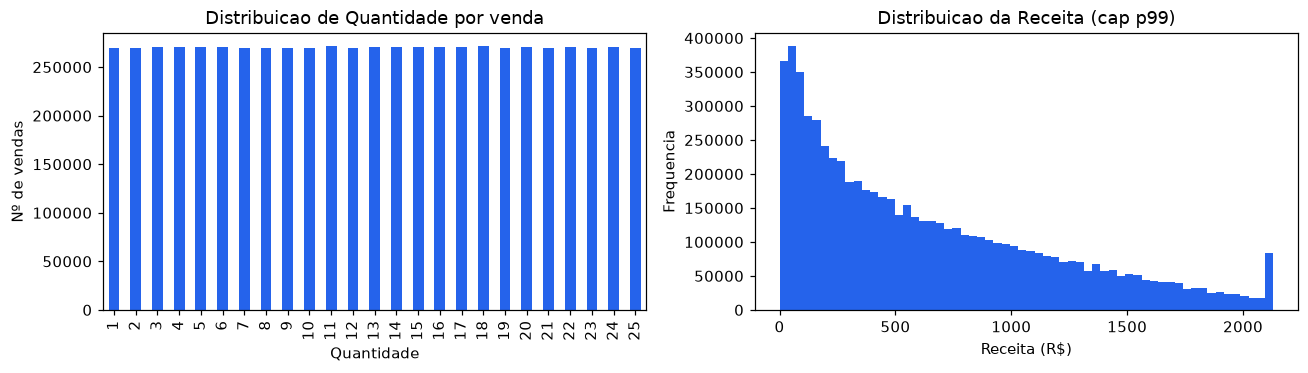

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sales.Quantity.value_counts().sort_index().plot(kind="bar", ax=axes[0], color=AZUL)
axes[0].set(title="Distribuicao de Quantidade por venda", xlabel="Quantidade", ylabel="Nº de vendas")
axes[1].hist(sales.Receita.clip(upper=sales.Receita.quantile(0.99)), bins=60, color=AZUL)
axes[1].set(title="Distribuicao da Receita (cap p99)", xlabel="Receita (R$)", ylabel="Frequencia")
plt.tight_layout(); plt.show()

## 5. Evolução temporal

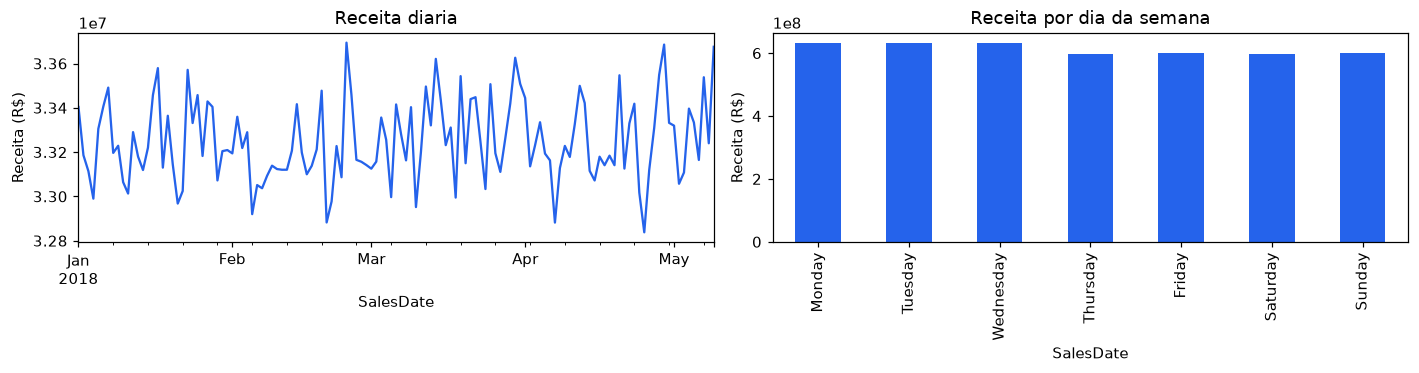

In [10]:
ts = sales.set_index("SalesDate").resample("D")["Receita"].sum()
ordem = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
vol_dow = sales.groupby(sales.SalesDate.dt.day_name())["Receita"].sum().reindex(ordem)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
ts.plot(ax=axes[0], color=AZUL); axes[0].set(title="Receita diaria", ylabel="Receita (R$)")
vol_dow.plot(kind="bar", ax=axes[1], color=AZUL); axes[1].set(title="Receita por dia da semana", ylabel="Receita (R$)")
plt.tight_layout(); plt.show()

## 6. Produtos e categorias

Top 10 produtos por receita:


,Receita (R$)
ProductID,
Bread - Calabrese Baguette,18868838.0
Shrimp - 31/40,18721942.0
Puree - Passion Fruit,18703480.0
Tia Maria,18685125.0
Zucchini - Yellow,18551658.0
Vanilla Beans,18530395.0
Beef - Inside Round,18334978.0
Grenadine,18331169.0
Lettuce - Treviso,18321893.0


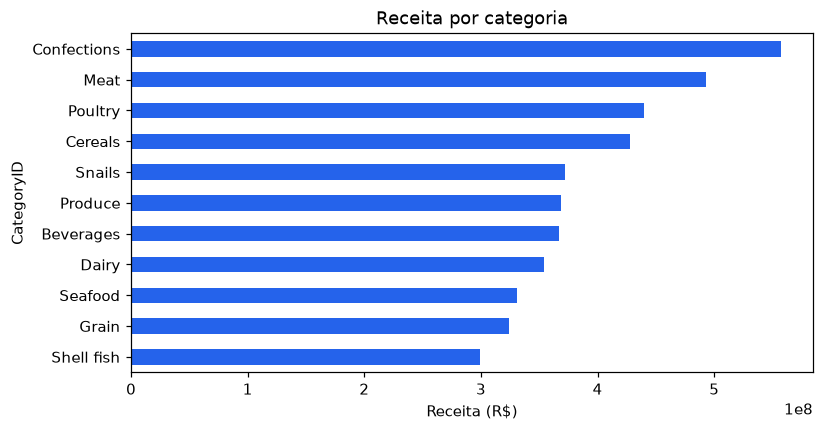

,% receita
CategoryID,
Confections,12.9
Meat,11.4
Poultry,10.2
Cereals,9.9
Snails,8.6
Produce,8.5
Beverages,8.5
Dairy,8.2
Seafood,7.6


In [11]:
nomes_prod = products.set_index("ProductID")["ProductName"]
top_prod = (sales.groupby("ProductID")["Receita"].sum()
            .sort_values(ascending=False).head(10).rename(index=nomes_prod))
print("Top 10 produtos por receita:")
display(top_prod.round(0).to_frame("Receita (R$)"))

cat_rev = sales.groupby("CategoryID")["Receita"].sum()
cat_rev.index = cat_rev.index.map(categories.set_index("CategoryID")["CategoryName"])
cat_rev = cat_rev.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
cat_rev.plot(kind="barh", ax=ax, color=AZUL); ax.invert_yaxis()
ax.set(title="Receita por categoria", xlabel="Receita (R$)"); plt.show()
display((cat_rev / cat_rev.sum() * 100).round(1).to_frame("% receita"))

## 7. Vendedores

23 vendedores | topo R$ 190,042,744 vs base R$ 186,320,422


,sum,count
SalesPersonID,,
Devon Brewer,190042744.0,294983
Shelby Riddle,189413136.0,293562
Katina Marks,189312927.0,293530
Desiree Stuart,189222585.0,293711
Darnell Nielsen,189135962.0,294744


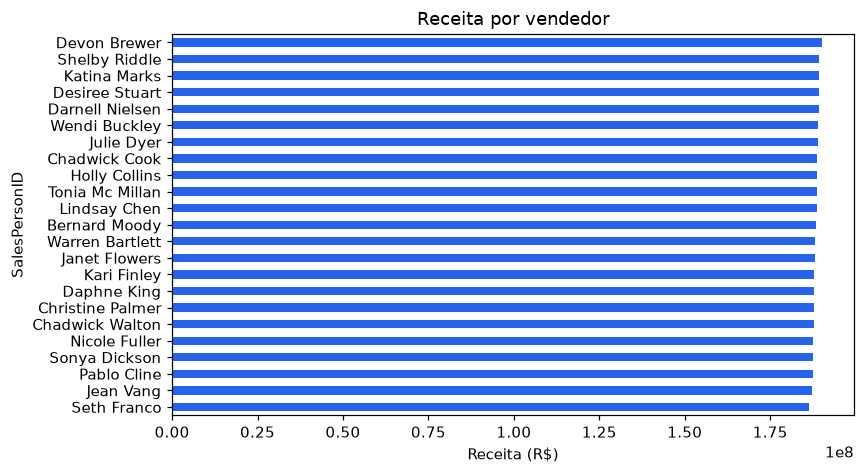

In [12]:
emp_name = (employees.assign(nome=employees.FirstName + " " + employees.LastName)
            .set_index("EmployeeID")["nome"])
sp = sales.groupby("SalesPersonID")["Receita"].agg(["sum", "count"]).sort_values("sum", ascending=False)
sp.index = sp.index.map(emp_name)

print(f"{len(sp)} vendedores | topo R$ {sp['sum'].max():,.0f} vs base R$ {sp['sum'].min():,.0f}")
display(sp.head(5).round(0))

fig, ax = plt.subplots(figsize=(8, 4.5))
sp["sum"].sort_values().plot(kind="barh", ax=ax, color=AZUL)
ax.set(title="Receita por vendedor", xlabel="Receita (R$)"); plt.show()

## 8. Clientes e geografia

In [13]:
cust_geo = customers.merge(cities, on="CityID", how="left").merge(countries, on="CountryID", how="left")
top_pais = cust_geo.CountryName.value_counts().head(10)
print(f"{customers.CustomerID.nunique():,} clientes | paises: {cust_geo.CountryName.nunique()} | cidades: {cities.CityID.nunique()}")
display(top_pais.to_frame("clientes"))

cust_rev = sales.groupby("CustomerID")["Receita"].sum().sort_values(ascending=False)
print(f"Top cliente: R$ {cust_rev.iloc[0]:,.0f} | mediana por cliente: R$ {cust_rev.median():,.0f}")

98,759 clientes | paises: 1 | cidades: 96


,clientes
CountryName,
United States,98759


Top cliente: R$ 130,324 | mediana por cliente: R$ 42,970


## 9. Principais conclusões
1. **Volume**: 6,76 mi de transações (01/01–09/05/2018), receita estimada de ~R$ 4,33 bi.
2. **`TotalPrice` inutilizável**: 100% zerada — receita recalculada via `products.Price`.
3. **Descontos**: só ~20% das vendas têm desconto (0, 10 ou 20%).
4. **Categoria líder**: *Confections* (~13% da receita); distribuição equilibrada.
5. **Equipe**: 23 vendedores com desempenho quase idêntico.
6. **Clientes**: 98.759, **todos nos EUA**, em 96 cidades.
7. **Sinais de dados sintéticos**: receitas quase iguais entre produtos/vendedores e quantidades uniformes.

# 10. Detecção de outliers
Analisamos valores atípicos em dois níveis:
- **Transação** (`Quantity`, `Price`, `Discount`, `Receita`) — métodos IQR e Z-score.
- **Agregado** (gasto por cliente, receita por produto, nº de vendas por cliente).

> **IQR**: outlier se valor < Q1 − 1.5·IQR ou > Q3 + 1.5·IQR.
> **Z-score**: outlier se |z| > 3 (mais de 3 desvios-padrão da média).

## 10.1 Outliers por transação — método IQR

In [14]:
def limites_iqr(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

cols = ["Quantity", "Price", "Discount", "Receita"]
resumo = []
for c in cols:
    lo, hi = limites_iqr(sales[c])
    mask = (sales[c] < lo) | (sales[c] > hi)
    resumo.append({"coluna": c, "lim_inf": round(lo, 2), "lim_sup": round(hi, 2),
                   "n_outliers": int(mask.sum()), "%": round(mask.mean()*100, 3)})
resumo_iqr = pd.DataFrame(resumo).set_index("coluna")
display(resumo_iqr)

,lim_inf,lim_sup,n_outliers,%
coluna,,,,
Quantity,-11.00,37.00,0,0.000
Price,-46.43,148.26,0,0.000
Discount,0.00,0.00,1351194,19.994
Receita,-1023.99,2188.38,49129,0.727


## 10.2 Boxplots

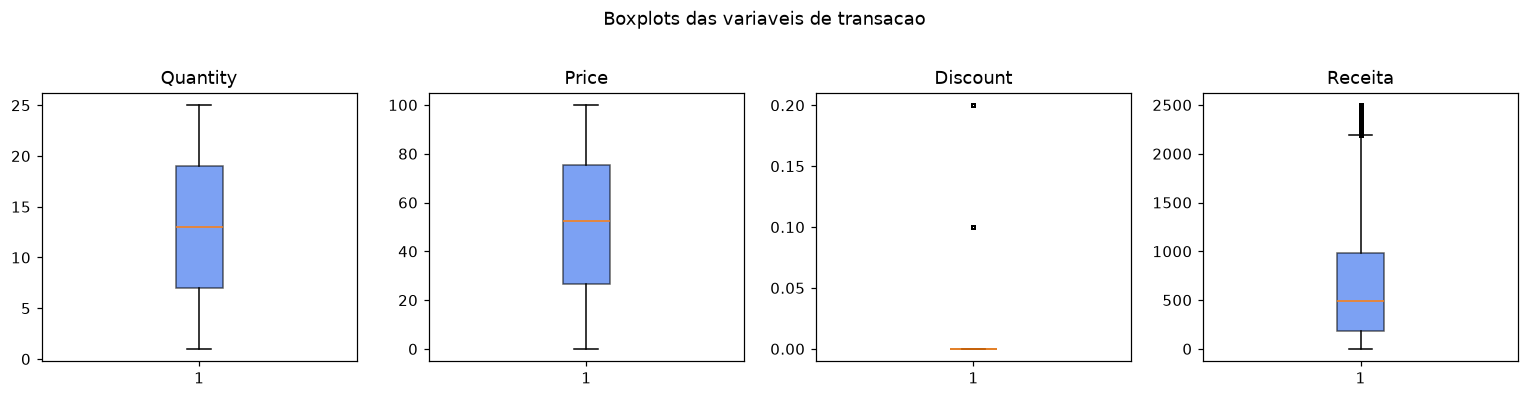

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, c in zip(axes, cols):
    ax.boxplot(sales[c].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=AZUL, alpha=0.6),
               flierprops=dict(marker="o", markersize=2, alpha=0.3))
    ax.set_title(c)
plt.suptitle("Boxplots das variaveis de transacao", y=1.02)
plt.tight_layout(); plt.show()

## 10.3 Comparação IQR × Z-score

In [16]:
from scipy import stats

comp = []
for c in cols:
    x = sales[c].astype("float64")
    lo, hi = limites_iqr(x)
    n_iqr = int(((x < lo) | (x > hi)).sum())
    z = np.abs(stats.zscore(x, nan_policy="omit"))
    n_z = int((z > 3).sum())
    comp.append({"coluna": c, "outliers_IQR": n_iqr, "outliers_Zscore(|z|>3)": n_z})
display(pd.DataFrame(comp).set_index("coluna"))

,outliers_IQR,outliers_Zscore(|z|>3)
coluna,,
Quantity,0,0
Price,0,0
Discount,1351194,0
Receita,49129,25059


## 10.4 Outliers em nível agregado

Clientes outliers por gasto total: 1 de 98,759 (0.00%)
Produtos outliers por receita:     0 de 452
Clientes outliers por nº de compras: 694 de 98,759


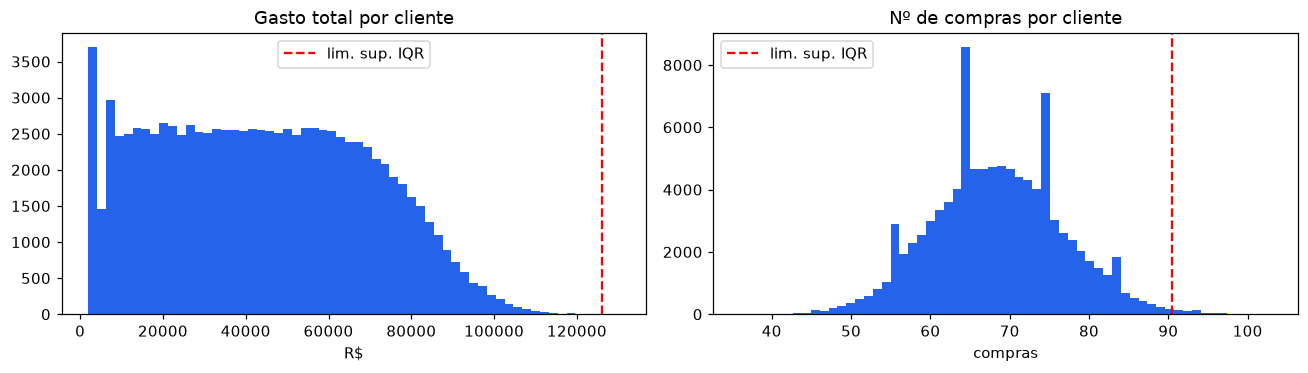

In [17]:
def outliers_iqr(s, k=1.5):
    lo, hi = limites_iqr(s, k)
    return s[(s < lo) | (s > hi)]

# gasto total por cliente
gasto_cli = sales.groupby("CustomerID")["Receita"].sum()
out_cli = outliers_iqr(gasto_cli)

# receita total por produto
rec_prod = sales.groupby("ProductID")["Receita"].sum()
out_prod = outliers_iqr(rec_prod)

# numero de compras por cliente
freq_cli = sales.groupby("CustomerID").size()
out_freq = outliers_iqr(freq_cli)

print(f"Clientes outliers por gasto total: {len(out_cli):,} de {len(gasto_cli):,} ({len(out_cli)/len(gasto_cli)*100:.2f}%)")
print(f"Produtos outliers por receita:     {len(out_prod):,} de {len(rec_prod):,}")
print(f"Clientes outliers por nº de compras: {len(out_freq):,} de {len(freq_cli):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(gasto_cli, bins=60, color=AZUL)
axes[0].axvline(limites_iqr(gasto_cli)[1], color="red", ls="--", label="lim. sup. IQR")
axes[0].set(title="Gasto total por cliente", xlabel="R$"); axes[0].legend()
axes[1].hist(freq_cli, bins=60, color=AZUL)
axes[1].axvline(limites_iqr(freq_cli)[1], color="red", ls="--", label="lim. sup. IQR")
axes[1].set(title="Nº de compras por cliente", xlabel="compras"); axes[1].legend()
plt.tight_layout(); plt.show()

## 10.5 Top clientes atípicos (maior gasto)

In [18]:
nome_cli = (customers.assign(nome=customers.FirstName + " " + customers.LastName)
            .set_index("CustomerID")["nome"])
top_out = out_cli.sort_values(ascending=False).head(10).rename(index=nome_cli)
display(top_out.round(0).to_frame("Gasto total (R$)"))

,Gasto total (R$)
CustomerID,
Wayne Chan,130324.0


## 10.6 Conclusões sobre outliers
- As variáveis de transação são **fortemente limitadas** (`Quantity` 1–25, `Discount` ∈ {0; 0,1; 0,2},
  `Price` 0,04–99,88), então a `Receita` também tem teto (~R$ 2.497). Isso reduz muito a presença
  de outliers "clássicos" — coerente com dados sintéticos.
- Os poucos outliers relevantes aparecem no **nível agregado** (clientes/produtos com volume acima do
  esperado pelo IQR), úteis para segmentar clientes de alto valor.
- IQR e Z-score tendem a divergir aqui: como as distribuições são quase uniformes/limitadas, o Z-score
  (|z|>3) sinaliza pouquíssimos pontos, enquanto o IQR captura as caudas agregadas.

uso de percentil para normalizar produtpo x cliente

uso de kmeans